<a href="https://colab.research.google.com/github/gabs-tr-data-analyst/telecom-analysis/blob/main/telecom_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [ ]:
plans.head(5)# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head(5)# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head(5)# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.


In [ ]:
# cantidad de nulos para users
print(users.isna().sum())# Cantidad de valores nulos)
print(users.isna().mean())# Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
print(usage.isna().sum())##nulos para usage
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- En el dataset de users, las columnas city y churn_date son las que tienen valores nulos. En cuanto a city, con 0.11725, se podría dejar como nulos por no afectar tanto o imputar con la moda, pero churn_date tiene 0.88350 podría eliminarse, pero como hace referencia al término del plan, sería bueno analizar si no se va a necesitar en un futuro.
- En el dataset usage, las columnas date, duration y length, tienen valores faltantes, con el 0.00125,  0.55190 y 0.44740, respectivamente, siendo duration la más alta con más del 50%. Se recomienda dejar en nulos date y a su vez, imputar duration y length porque pueden afectar en los cálculos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
users.describe()# explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` no presenta outliers, lo que indica que los registros por usuario no tienen anomalías. Su desviación estándar es baja y su promedio es coherente con la mediana.
- La columna `age` tiene sentinels como -999 valor inválido que altera todo el cálculo. Hay un sesgo a la izquierda notable porque la mediana es menor que la media. Se observa gran dispersión de datos, por esa desviación estándar elevada.

In [ ]:
usage.describe()# explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`tienen relación una con otra, coherencia en los mínimos y máximos sin valores inválidos.
- Las columnas "duration" y "length" tienen outliers que se observan en los valores máximos y en la diferencia con el IQR.

In [ ]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].nunique()

city    7
plan    2
dtype: int64

In [ ]:
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

In [ ]:
users['plan'].value_counts()

Basico     2595
Premium    1405
Name: plan, dtype: int64

- La columna `city` contiene una fila con un valor indefinido pero que involucra 96 regustros.
- La columna `plan` sólo cuenta con 2 categorías, sin valores inválidos.

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False) # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` sólo cuenta con 2 categorías, sin valores inválidos.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- Encontramos sentinels en age (-999), que podemos imputar por la mediana.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce") # completa el código

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce") # completa el código

In [ ]:
# Recargar el dataset original
users = pd.read_csv('/datasets/users_latam.csv')

users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

años_presentes = users['reg_date'].dt.year.unique()
print("Años presentes en los datos:")
print(sorted(años_presentes))

Años presentes en los datos:
[2022, 2023, 2024, 2026]


En `reg_date`, se muestra el 2026 como el último año, siendo que los registros de este dataset deberían estar hasta 2024

In [ ]:
# Revisar los años presentes en `date` de usage
años_presentes = usage['date'].dt.year.unique()
print("Años presentes en los datos:")
print(sorted(años_presentes))


Años presentes en los datos:
[2024.0, nan]


En `date`, aparecen valores inválidos.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- Para los registros de 2026 se recomendaría imputar con el año límite superior que es 2024.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', 'NA')

# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
NA           96
Name: city, dtype: int64

In [ ]:
# Luego limpiar correctamente las fechas futuras
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

print("Años después de limpieza:")
print(users['reg_date'].dt.year.value_counts(dropna=False))

Años después de limpieza:
2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Se observa que duration cuenta con 99% nulos en textos y 0% en llamadas; mientras que length tiene el patrón opuesto (0% nulos en textos, ~99% en llamadas).
Encontramos que sí son MAR pues dependen del type, pero no se deben imputar porque obedecen a la naturaleza del negocio.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
usage["is_minutes"] = (usage["type"] == "duration").astype(int)

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    total_messages = ("is_text", "sum"),
    total_calls    = ("is_call", "sum"),
    total_minutes  = ("duration", "sum")

).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,total_messages,total_calls,total_minutes
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "total_messages": "cant_mensajes",
    "total_calls":    "cant_llamadas",
    "total_minutes":  "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = user_profile = users.merge(usage_agg, on="user_id", how="left")

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True).mul(100).round(1)

Basico     64.9
Premium    35.1
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

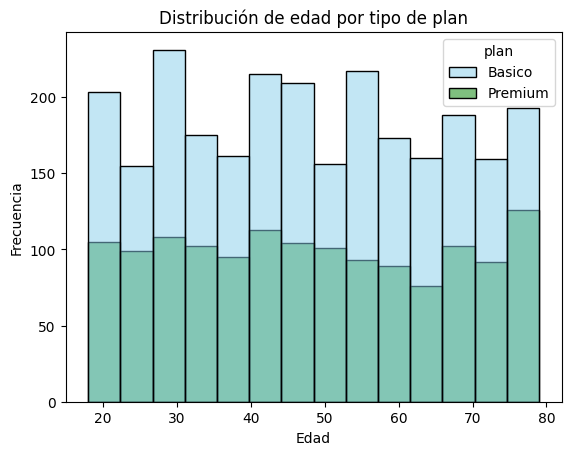

In [ ]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile, x="age", bins=14, hue="plan", palette=["skyblue", "green"])

plt.title("Distribución de edad por tipo de plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()


💡Insights:
- En el plan premium encontramos baja dispersión, una distribución normal pero sobresalen clientes de mas de 70 años.
- En el plan básico, observamos mayor frecuencia en clientes de 30 años. Hay mayor dispersión, pero la distribución se podría seguir considerando simétrica.

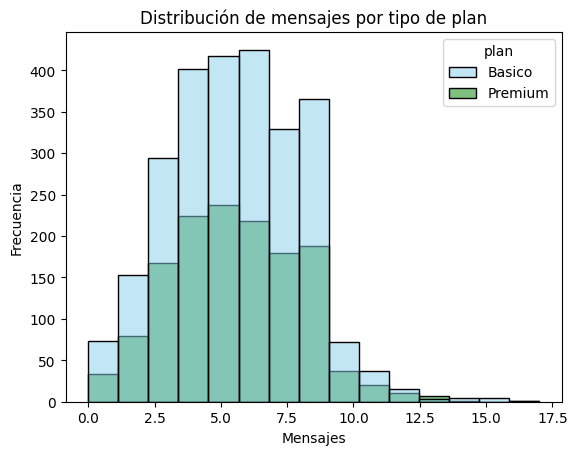

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x="cant_mensajes", bins=15, hue="plan", palette=["skyblue", "green"])

plt.title("Distribución de mensajes por tipo de plan")
plt.xlabel("Mensajes")
plt.ylabel("Frecuencia")
plt.show()


💡Insights:
- Tanto el plan premium como el básico muestran un sesgo a la derecha. Demuestra que no influye el tipo de plan para el comportamiento de clientes en cuanto a mensajes.
- Encontramos outliers en ambos casos y una dispersión alta en los 2 planes.

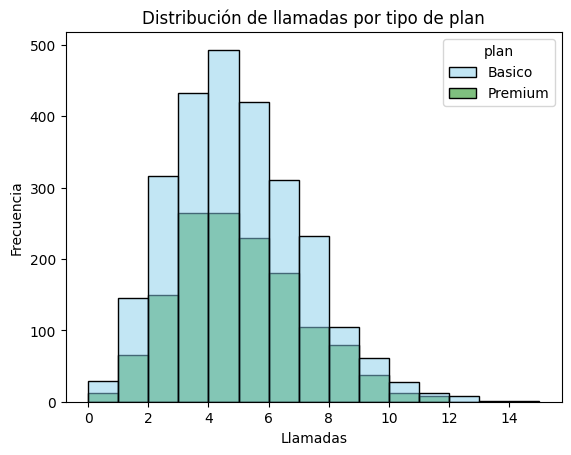

In [ ]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x="cant_llamadas", bins= 15, hue="plan", palette=["skyblue", "green"])

plt.title("Distribución de llamadas por tipo de plan")
plt.xlabel("Llamadas")
plt.ylabel("Frecuencia")
plt.show()


💡Insights:
- En proporción, hay un menor número de llamadas que de mensajes en clientes de plan premium (comparando los 2 histogramas).
- Por otro lado, en este podemos ver que también hay considerable dispersión en ambos planes, así como un sesgo a la derecha, indicando pocos clientes tanto en básico como en premium que realizan un mayor número de llamadas. Por ello los outliers.

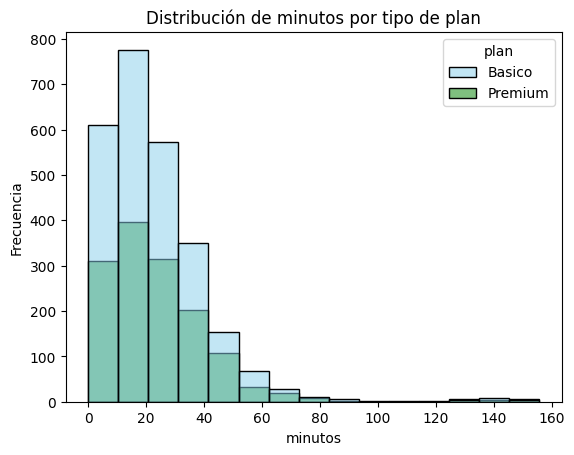

In [ ]:
# Histograma para visualizar la cant_minutos_llamada

sns.histplot(data=user_profile, x="cant_minutos_llamada", bins= 15, hue="plan", palette=["skyblue", "green"])

plt.title("Distribución de minutos por tipo de plan")
plt.xlabel("minutos")
plt.ylabel("Frecuencia")
plt.show()

💡Insights:
- Al tratarse de la sumatoria de minutos, era de esperarse la cantidad de outliers. Así como el comportamiento similar al histograma de llamadas.
- Se presenta un fuerte sesgo a la derecha, que se puede explicar por la tabla anterior donde calculamos el resumen estadístico, ya que el valor máximo del total de minutos es de 155.690000 mientras que el Q3 es de 31.415000.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

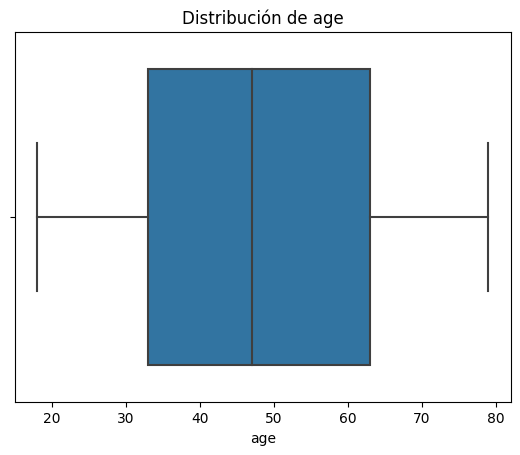

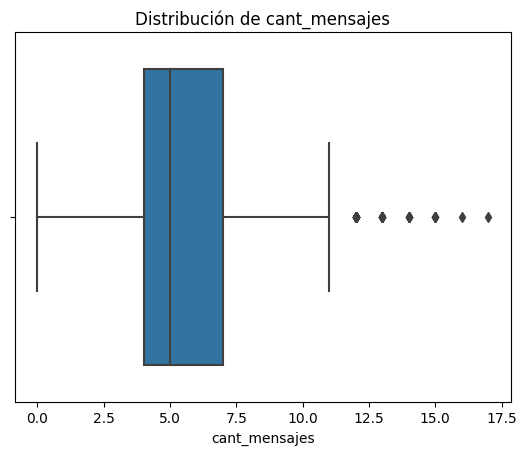

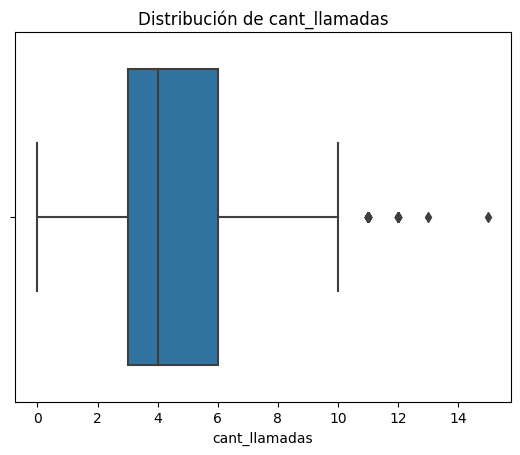

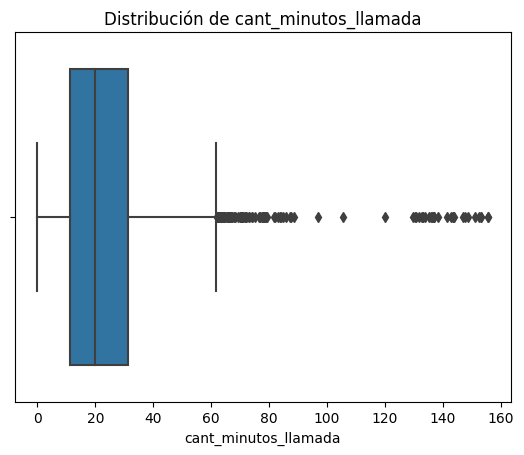

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


for col in columnas_numericas:
    sns.boxplot(x=user_profile[col])
    plt.title(f"Distribución de {col}")
    plt.show()

💡Insights:
- Age: No presenta outliers.
- cant_mensajes: Presenta más outliers que las llamadas.
- cant_llamadas: Se observan outliers.
- cant_minutos_llamada: También hay outliers, pero en mayor proporción, posiblemente por tratarse de la sumatoria de minutos.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR

    outliers = user_profile[user_profile[col] > limite_superior]
    print(f"{col}: Q1={Q1:.2f} | Q3={Q3:.2f} | Límite superior={limite_superior:.2f} | Outliers={len(outliers)}")

cant_mensajes: Q1=4.00 | Q3=7.00 | Límite superior=11.50 | Outliers=46
cant_llamadas: Q1=3.00 | Q3=6.00 | Límite superior=10.50 | Outliers=30
cant_minutos_llamada: Q1=11.12 | Q3=31.41 | Límite superior=61.86 | Outliers=109


In [ ]:
 # Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:

- Para los casos de cant_mensajes y cant_llamadas, encontramos que los valores máximos (17 y 15) son cercanos al límite superior (11.5 y 10.5) respectivamente.
No representan un salto alarmante y son comportamientos completamente posibles dado el giro de la empresa. **Por ello se recomienda mantener los outliers**.

- Por otro lado en cant_minutos_llamada encontramos 109 outliers, pero no es una anomalía, es un segmento de usuarios. La brecha entre el límite (61.86) y el máximo (155) sugiere usuarios con patrones de uso intensivo, que podríamos segmentar más adelante. **Eliminarlos sesgaría el análisis, se recomienda mantenerlos**.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_mensajes'] < 5) & (user_profile['cant_llamadas'] < 5), 'Bajo uso',
    np.where(
        (user_profile['cant_mensajes'] < 10) & (user_profile['cant_llamadas'] < 10), 'Uso medio', 'Alto uso'
    )
)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    (user_profile['age'] < 30),'Joven',
    np.where(
        (user_profile['age'] < 60), 'Adulto', 'Adulto Mayor'
    )
)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

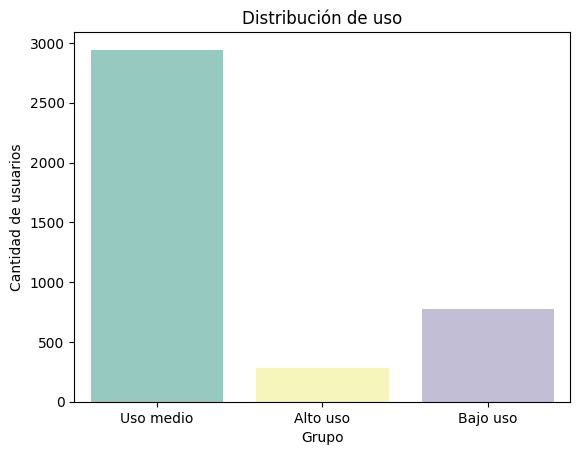

In [ ]:
sns.countplot(data=user_profile, x="grupo_uso", palette="Set3")
plt.title("Distribución de uso")
plt.xlabel("Grupo")
plt.ylabel("Cantidad de usuarios")
plt.show()

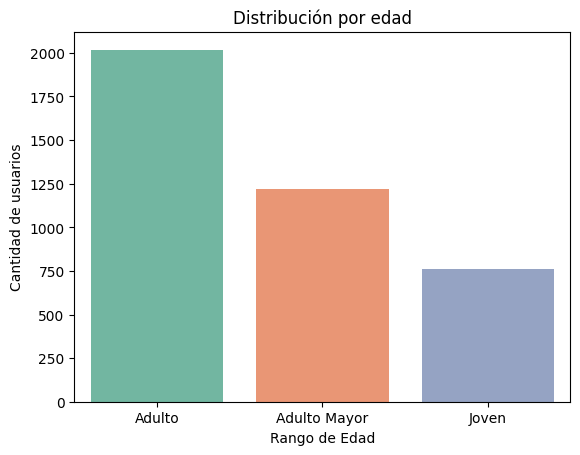

In [ ]:
# Visualización de los segmentos por edad

sns.countplot(data=user_profile, x="grupo_edad", palette="Set2")
plt.title("Distribución por edad")
plt.xlabel("Rango de Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()

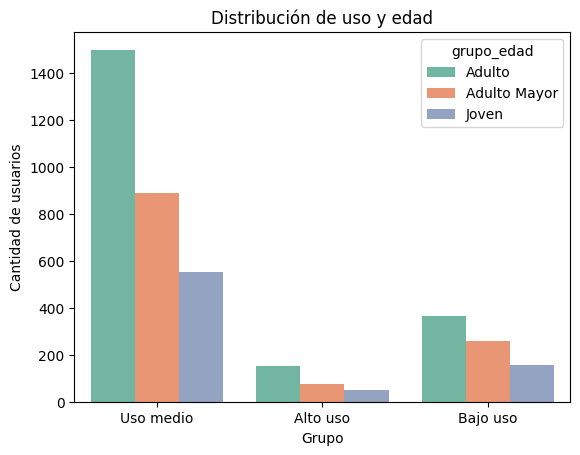

In [ ]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x="grupo_uso", hue="grupo_edad", palette="Set2")
plt.title("Distribución de uso y edad")
plt.xlabel("Grupo")
plt.ylabel("Cantidad de usuarios")
plt.show()

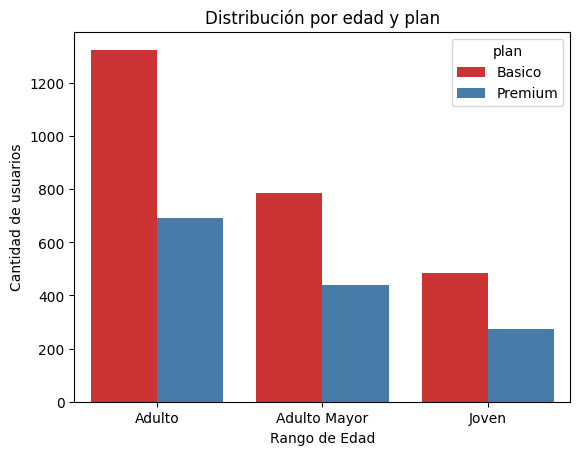

In [ ]:
# Visualización de los segmentos por edad

sns.countplot(data=user_profile, x="grupo_edad", hue="plan", palette="Set1")
plt.title("Distribución por edad y plan")
plt.xlabel("Rango de Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()


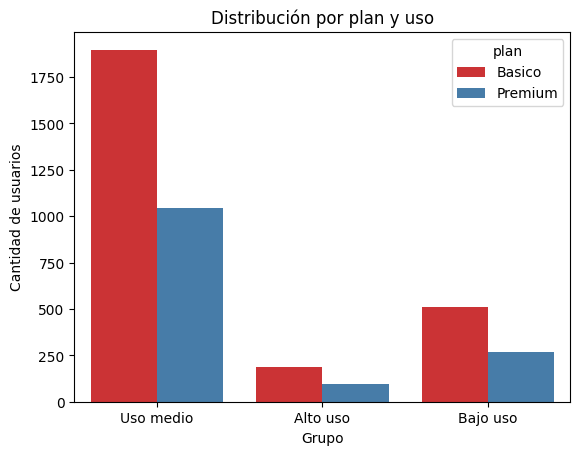

In [ ]:
sns.countplot(data=user_profile, x="grupo_uso", hue="plan", palette="Set1")
plt.title("Distribución por plan y uso")
plt.xlabel("Grupo")
plt.ylabel("Cantidad de usuarios")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- Las columnas 'reg_date' y 'date' son del tipo object, se cambiaron a tipo fecha.
- En el dataset de users, las columnas city y churn_date son las que tienen valores nulos, con 0.11725 y 0.88350 respectivamente.
- En el dataset usage, las columnas date, duration y length, tienen valores faltantes, con el 0.00125,  0.55190 y 0.44740, respectivamente, siendo duration la más alta con más del 50%.
- La columna `age` tiene sentinels como -999 valor inválido que altera todo el cálculo. Hay un sesgo a la izquierda notable porque la mediana es menor que la media. Se observa gran dispersión de datos, por esa desviación estándar elevada.
-  La columna `city` contiene una fila con un valor indefinido pero que involucra 96 regustros.

📈 **Manejo de Outliers**
- Para los casos de cant_mensajes y cant_llamadas, encontramos que los valores máximos (17 y 15) son cercanos al límite superior (11.5 y 10.5) respectivamente.
No representan un salto alarmante y son comportamientos completamente posibles dado el giro de la empresa. **Por ello se recomienda mantener los outliers**.
- Por otro lado en cant_minutos_llamada encontramos 109 outliers, pero no es una anomalía, es un segmento de usuarios. La brecha entre el límite (61.86) y el máximo (155) sugiere usuarios con patrones de uso intensivo, que podríamos segmentar más adelante. **Eliminarlos sesgaría el análisis, se recomienda mantenerlos**.
  
🔍 **Segmentos por Edad**
- Los segmentos por edad se agruparon en categorías 'Joven' (todos los menores de 30años); 'Adulto' (menores de 60 y mayores de 30) y 'Adulto Mayor' (de 60 en adelante).
- Se observó que el segmento de 'Adulto' es el de la mayor cantidad de usuarios en el plan 'básico' y de igual forma prevalece en el uso medio de telefonía.
- Dato importante es que en la distribución por edad podemos ver que tanto 'Adulto' y 'Adulto mayor' están por encima de 'Joven'. Pregunta para reflexionar ¿Por qué los jóvenes no están contratando los planes?
- Los 3 segmentos cuentan con menos usuarios en plan premium que en el básico, pero proporcionalmente hablando, en el segmento 'Joven' hay una menor brecha entre el básico y el premium.

📊 **Segmentos por Nivel de Uso**
- Los segmentos por nivel de uso se agruparon en 'Bajo uso', 'Uso medio' y 'Alto uso'.
- Podemos apreciar una mayor frecuencia en 'Uso medio', con prevalencia del plan básico y el segmento 'Adulto'.
- En los 3 segmentos observamos  que en cuanto a edades, los 'Adultos' sobresalen de los 'Adultos mayores' y 'jóvenes'.
- Poniendo atención en el 'Alto uso', notamos que la diferencia entre plan Básico y plan Premium es menor, proporcionalmente hablando.
- El segmento de jóvenes es más chico considerablemente que el de adultos mayores, sin embargo, en cuanto a uso, concretamente en 'Alto uso', no se nota una gran diferencia entre ambos.

➡️ Esto sugiere que la base de usuarios está dominada por adultos y adultos mayores, por ende el segmento joven representa una oportunidad de crecimiento sin explotar. Debido a que el grueso de usuarios se concentra en uso medio con plan básico, existe un potencial real de upselling hacia planes superiores, sobre todo considerando que tanto en el segmento joven como en el de adultos mayores se observa un comportamiento similar en alto uso, lo que indica que el nivel de consumo responde más al perfil de necesidades que a la edad.

💡 **Recomendaciones**
- Para captar al **segmento joven** se recomienda diseñar campañas en redes sociales con AB testing — probando creativos con beneficios como datos ilimitados o acceso a plataformas de streaming — aprovechando que este segmento muestra menor brecha entre plan básico y premium, lo que sugiere mayor disposición a pagar.
- Para el **adulto mayor**, Facebook sigue siendo el canal más efectivo, por ende una campaña con mensajes simples enfocados en conectividad familiar y soporte personalizado puede impulsar la migración hacia planes superiores entre los usuarios de alto uso con plan básico.